In [2]:
# import libraries
import numpy as np
import pandas as pd 
from matplotlib import pyplot as plt
import matplotlib
%matplotlib inline
import seaborn as sns
from collections import Counter
from sklearn.metrics import mean_squared_error
from pandas import concat
from pandas import Series, DataFrame
import statsmodels.api as sm


In [3]:
bird = pd.read_csv('Bird Strikes data.csv')
bird = bird.dropna(how='all')


In [24]:
bird.shape

(25558, 26)

In [5]:
bird.head()

,Record ID,Aircraft: Type,Airport: Name,Altitude bin,Aircraft: Make/Model,Wildlife: Number struck,Wildlife: Number Struck Actual,Effect: Impact to flight,FlightDate,Effect: Indicated Damage,...,Remains of wildlife sent to Smithsonian,Remarks,Wildlife: Size,Conditions: Sky,Wildlife: Species,Pilot warned of birds or wildlife?,Cost: Total $,Feet above ground,Number of people injured,Is Aircraft Large?
0,202152,Airplane,LAGUARDIA NY,> 1000 ft,B-737-400,Over 100,859,Engine Shut Down,23-11-2000 00:00,Caused damage,...,False,FLT 753. PILOT REPTD A HUNDRED BIRDS ON UNKN T...,Medium,No Cloud,Unknown bird - medium,N,"30,736","1,500",0,Yes
1,208159,Airplane,DALLAS/FORT WORTH INTL ARPT,< 1000 ft,MD-80,Over 100,424,NaN,25-07-2001 00:00,Caused damage,...,False,102 CARCASSES FOUND. 1 LDG LIGHT ON NOSE GEAR ...,Small,Some Cloud,Rock pigeon,Y,0,0,0,No
2,207601,Airplane,LAKEFRONT AIRPORT,< 1000 ft,C-500,Over 100,261,NaN,14-09-2001 00:00,No damage,...,False,FLEW UNDER A VERY LARGE FLOCK OF BIRDS OVER AP...,Small,No Cloud,European starling,N,0,50,0,No
3,215953,Airplane,SEATTLE-TACOMA INTL,< 1000 ft,B-737-400,Over 100,806,Precautionary Landing,05-09-2002 00:00,No damage,...,False,"NOTAM WARNING. 26 BIRDS HIT THE A/C, FORCING A...",Small,Some Cloud,European starling,Y,0,50,0,Yes
4,219878,Airplane,NORFOLK INTL,< 1000 ft,CL-RJ100/200,Over 100,942,NaN,23-06-2003 00:00,No damage,...,False,NO DMG REPTD.,Small,No Cloud,European starling,N,0,50,0,No


In [6]:
bird.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25558 entries, 0 to 25557
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype 
---  ------                                   --------------  ----- 
 0   Record ID                                25558 non-null  int64 
 1   Aircraft: Type                           25429 non-null  object
 2   Airport: Name                            25429 non-null  object
 3   Altitude bin                             25429 non-null  object
 4   Aircraft: Make/Model                     25558 non-null  object
 5   Wildlife: Number struck                  25429 non-null  object
 6   Wildlife: Number Struck Actual           25558 non-null  int64 
 7   Effect: Impact to flight                 2078 non-null   object
 8   FlightDate                               25429 non-null  object
 9   Effect: Indicated Damage                 25558 non-null  object
 10  Aircraft: Number of engines?             25291 non-null  o

In [7]:
bird.drop(['Record ID'], axis=1).describe()


,Wildlife: Number Struck Actual,Number of people injured
count,25558.000000,25558.000000
mean,2.691525,0.001056
std,12.793975,0.050420
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,1.000000,0.000000
max,942.000000,6.000000


In [8]:
bird['Cost: Total $'] = pd.to_numeric(bird['Cost: Total $'], errors='coerce')

bird_dmg = bird.loc[(bird['Effect: Indicated Damage'] != 'No damage') | 
                    (bird['Cost: Total $'] > 0) ]

In [9]:
count_air_type = DataFrame({'count' : bird.groupby( ['Aircraft: Number of engines?'] ).size()}).reset_index()
count_air_type.sort_values(['count'], ascending=0)

,Aircraft: Number of engines?,count
1,2,23025
0,1,1313
2,3,564
3,4,388
4,C,1


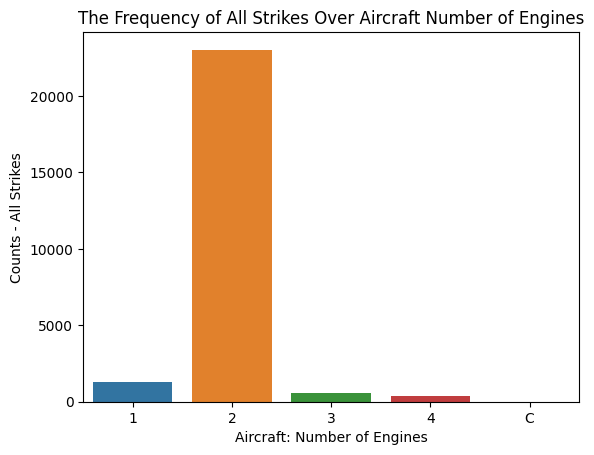

In [10]:
bird.loc[(bird['Aircraft: Number of engines?'] == 'S'),'Aircraft: Number of engines?'] = np.nan

# update bird_dmg as well
bird_dmg = bird.loc[(bird['Effect: Indicated Damage'] != 'No damage') | 
                    (bird['Cost: Total $'] > 0) ]

# re-generate count table
count_air_type = DataFrame({'count' : bird.groupby( ['Aircraft: Number of engines?'] ).size()}).reset_index()
# plot the frequency of Aircraft: Number of engines?
fig_air_type = sns.barplot(x=u'Aircraft: Number of engines?', y='count', data=count_air_type)
fig_air_type.set(xlabel='Aircraft: Number of Engines', ylabel='Counts - All Strikes');
fig_air_type.set_title('The Frequency of All Strikes Over Aircraft Number of Engines');

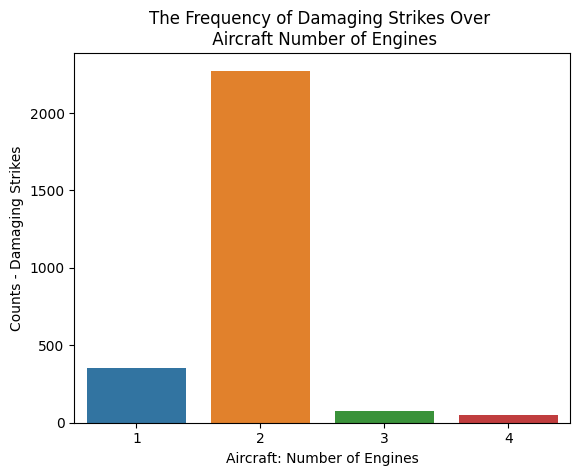

In [11]:
# table for damaging stikes
count_air_type0 = DataFrame({'count' : bird_dmg.groupby( [ 'Aircraft: Number of engines?'] ).size()}).reset_index()
count_air_type0['All Strikes Counts'] = count_air_type['count']
count_air_type0['Damage Rate'] = count_air_type0['count']/count_air_type0['All Strikes Counts']
# plot the frequency of Aircraft: Number of engines?
fig_air_type0 = sns.barplot(x=u'Aircraft: Number of engines?', y='count', data=count_air_type0)
fig_air_type0.set(xlabel='Aircraft: Number of Engines', ylabel='Counts - Damaging Strikes');
fig_air_type0.set_title('The Frequency of Damaging Strikes Over \n Aircraft Number of Engines');

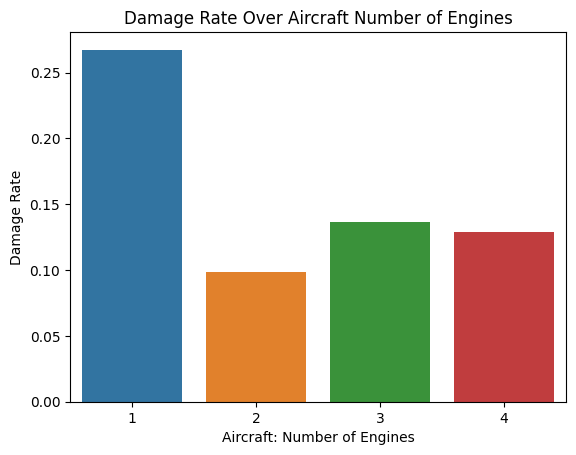

In [12]:
# plot the damage rate of Aircraft: Number of engines?
fig_air_type01 = sns.barplot(x=u'Aircraft: Number of engines?', y='Damage Rate', data=count_air_type0)
fig_air_type01.set(xlabel='Aircraft: Number of Engines', ylabel='Damage Rate');
fig_air_type01.set_title('Damage Rate Over Aircraft Number of Engines');

In [13]:
count_air_n_eng = DataFrame({'count' : bird.groupby( ['Aircraft: Airline/Operator'] ).size()}).reset_index()
count_air_n_eng.sort_values(['count'], ascending=0).head(10)

,Aircraft: Airline/Operator,count
250,SOUTHWEST AIRLINES,4628
69,BUSINESS,3074
45,AMERICAN AIRLINES,2058
112,DELTA AIR LINES,1349
46,AMERICAN EAGLE AIRLINES,932
246,SKYWEST AIRLINES,891
274,US AIRWAYS*,797
166,JETBLUE AIRWAYS,708
272,UPS AIRLINES,590
273,US AIRWAYS,540


In [14]:
count_air_n_eng0 = DataFrame({'count' : bird_dmg.groupby( ['Aircraft: Airline/Operator'] ).size()}).reset_index()
count_air_n_eng0.sort_values(['count'], ascending=0).head(10)

,Aircraft: Airline/Operator,count
37,BUSINESS,758
133,SOUTHWEST AIRLINES,359
21,AMERICAN AIRLINES,146
59,DELTA AIR LINES,136
119,PRIVATELY OWNED,130
87,JETBLUE AIRWAYS,73
22,AMERICAN EAGLE AIRLINES,72
146,US AIRWAYS*,65
131,SKYWEST AIRLINES,65
142,UNITED AIRLINES,53


In [15]:
count_air_make = DataFrame({'count' : bird.groupby( ['Aircraft: Make/Model'] ).size()}).reset_index()
count_air_make.sort_values(['count'], ascending=0).head(10)

,Aircraft: Make/Model,count
42,B-737-700,2488
38,B-737-300,2309
152,CL-RJ100/200,1951
6,A-320,1193
5,A-319,1000
51,B-757-200,992
203,EMB-145,990
43,B-737-800,678
278,MD-82,638
31,B-717-200,577


In [16]:
count_air_make0 = DataFrame({'count' : bird_dmg.groupby( ['Aircraft: Make/Model'] ).size()}).reset_index()
count_air_make0.sort_values(['count'], ascending=0).head(10)

,Aircraft: Make/Model,count
29,B-737-700,195
26,B-737-300,194
113,CL-RJ100/200,132
5,A-320,121
36,B-757-200,108
4,A-319,88
74,C-172,84
209,PA-28,61
146,EMB-145,60
30,B-737-800,59


In [17]:
# top 10 bird species - all strikes
count_species = DataFrame({'count' : bird.groupby( ['Wildlife: Species'] ).size()}).reset_index()
count_species.sort_values(['count'], ascending=0).head(10)

,Wildlife: Species,count
298,Unknown bird - small,10505
297,Unknown bird - medium,4318
187,Mourning dove,898
111,European starling,885
296,Unknown bird - large,797
252,Rock pigeon,596
25,Barn swallow,579
162,Killdeer,470
9,American kestrel,444
243,Red-tailed hawk,412


In [18]:
# top 10 bird species causing damages
count_species0 = DataFrame({'count' : bird_dmg.groupby( ['Wildlife: Species'] ).size()}).reset_index()
count_species0.sort_values(['count'], ascending=0).head(10)

,Wildlife: Species,count
141,Unknown bird - medium,568
142,Unknown bird - small,430
140,Unknown bird - large,290
34,Canada goose,213
112,Red-tailed hawk,108
139,Turkey vulture,99
120,Rock pigeon,86
152,White-tailed deer,79
89,Mourning dove,61
53,European starling,55


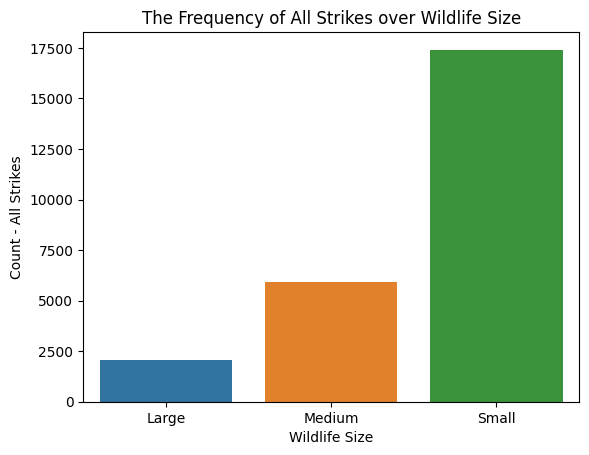

In [19]:
# count of strikes by bird size 
count_bird = DataFrame({'count' : bird.groupby( ['Wildlife: Size'] ).size()}).reset_index()
# plot the frequency of all strikes over Wildlife: Size
fig_bird = sns.barplot(x=u'Wildlife: Size', y='count', data=count_bird)
fig_bird.set(ylabel='Count - All Strikes',xlabel='Wildlife Size');
fig_bird.set_title('The Frequency of All Strikes over Wildlife Size');

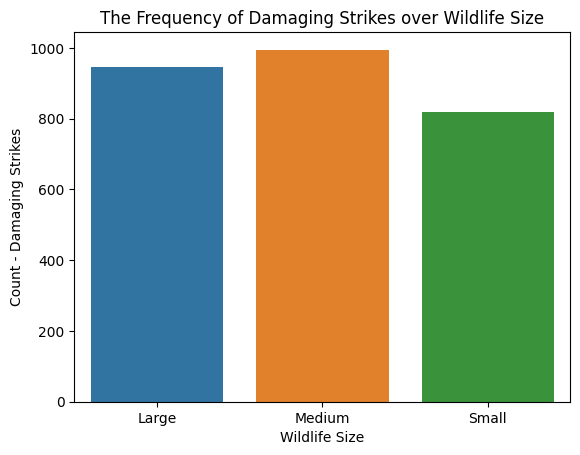

In [20]:
# count of strikes by bird size
count_bird0 = DataFrame({'count' : bird_dmg.groupby( ['Wildlife: Size'] ).size()}).reset_index()
count_bird0['All Strikes Counts'] = count_bird['count']
count_bird0['Damage Rate'] = count_bird0['count']/count_bird0['All Strikes Counts']

# plot the frequency of damaging strikes Wildlife: Number struck and Wildlife: Size
fig_bird0 = sns.barplot(x=u'Wildlife: Size', y='count', data=count_bird0)
fig_bird0.set(ylabel='Count - Damaging Strikes',xlabel='Wildlife Size');
fig_bird0.set_title('The Frequency of Damaging Strikes over Wildlife Size');

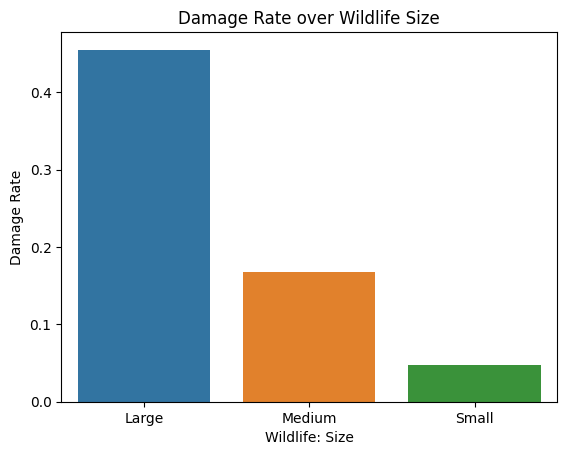

In [21]:
# plot damage rate over Wildlife: Size
fig_bird01 = sns.barplot(x=u'Wildlife: Size', y=u'Damage Rate', data=count_bird0)
fig_bird01.set(xlabel='Wildlife: Size', ylabel='Damage Rate');
fig_bird01.set_title('Damage Rate over Wildlife Size');

In [22]:
# There are a lot of missing data in these variables, but since the phase of the flight is available 
# some remedy is done here by filling in reasonalble values
bird.loc[ (bird['Miles from airport'].isnull()) & ( (bird['When: Phase of flight'] == 'Take-off run') |
          (bird['When: Phase of flight'] == 'Parked') | (bird['When: Phase of flight'] == 'Taxi') |
          (bird['When: Phase of flight'] == 'Landing Roll') ),'Miles from airport'] = 0
bird.loc[ (bird['Feet above ground'].isnull()) & ( (bird['When: Phase of flight'] == 'Take-off run') |
          (bird['When: Phase of flight'] == 'Parked') | (bird['When: Phase of flight'] == 'Taxi') |
          (bird['When: Phase of flight'] == 'Landing Roll') ),'Feet above ground'] = 0

KeyError: 'Miles from airport'

In [ ]:
DataFrame({'count' : bird.groupby( ['Altitude bin'] ).size()}).reset_index()

,Altitude bin,count
0,< 1000 ft,20556
1,> 1000 ft,4873


C:\Users\Aaminah masarrath\AppData\Local\Temp\ipykernel_27124\1713122184.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  hist_altitude = sns.distplot(bird['Feet above ground'].dropna(), kde=False)


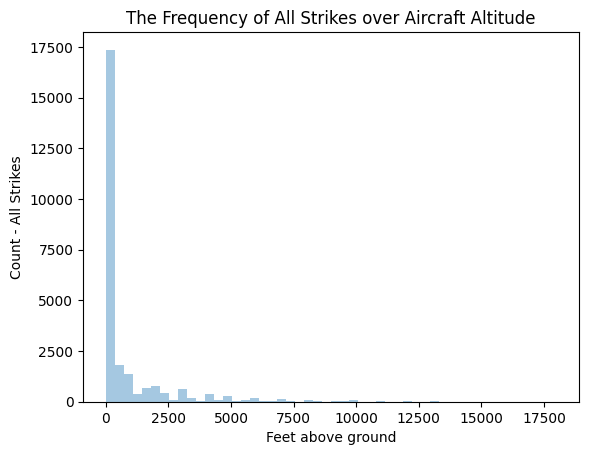

In [ ]:
# histogram of aircraft altitude information

bird['Feet above ground'] = pd.to_numeric(bird['Feet above ground'].str.replace(',', ''), errors='coerce')
hist_altitude = sns.distplot(bird['Feet above ground'].dropna(), kde=False)
hist_altitude.set_title('The Frequency of All Strikes over Aircraft Altitude')
hist_altitude.set(ylabel='Count - All Strikes')
plt.show()

C:\Users\Aaminah masarrath\AppData\Local\Temp\ipykernel_27124\691208873.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bird_dmg['Feet above ground'] = pd.to_numeric(bird_dmg['Feet above ground'].str.replace(',', ''), errors='coerce')
C:\Users\Aaminah masarrath\AppData\Local\Temp\ipykernel_27124\691208873.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  hist_altitude0 = sns.distplot(bird_dmg['Feet above gro

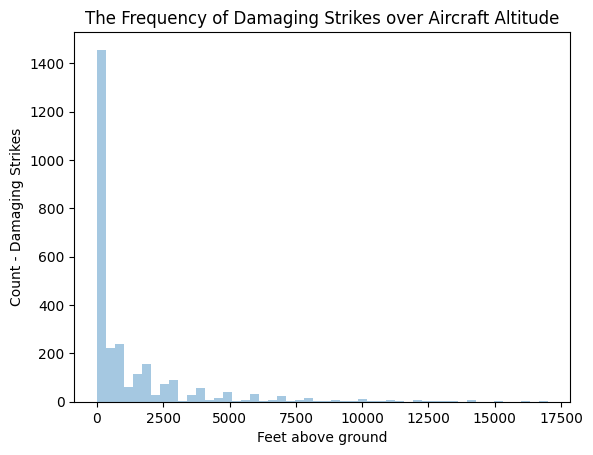

In [ ]:

bird_dmg['Feet above ground'] = pd.to_numeric(bird_dmg['Feet above ground'].str.replace(',', ''), errors='coerce')
hist_altitude0 = sns.distplot(bird_dmg['Feet above ground'].dropna(), kde=False)

hist_altitude0.set_title('The Frequency of Damaging Strikes over Aircraft Altitude')
hist_altitude0.set(ylabel='Count - Damaging Strikes')
plt.show()

In [ ]:
# rate of aircraft below 1000 and 5000 ft for all strikes
rate_1000 = len( bird.loc[bird['Altitude bin']=='< 1000 ft','Altitude bin'] ) / len( bird.loc[(bird['Altitude bin']=='< 1000 ft') | (bird['Altitude bin']=='> 1000 ft'),'Altitude bin'] )
rate_5000 = len( bird.loc[bird['Feet above ground']<5000,'Feet above ground'] ) / len( bird.loc[~(bird['Feet above ground'].isnull()),'Feet above ground'] )
# rate of aircraft below 1000 and 5000 ft for damaging strikes
rate_1000 = len( bird_dmg.loc[bird_dmg['Altitude bin']=='< 1000 ft','Altitude bin'] ) / len( bird_dmg.loc[(bird_dmg['Altitude bin']=='< 1000 ft') | (bird_dmg['Altitude bin']=='> 1000 ft'),'Altitude bin'] )
rate_5000 = len( bird_dmg.loc[bird_dmg['Feet above ground']<5000,'Feet above ground'] ) / len( bird_dmg.loc[~(bird_dmg['Feet above ground'].isnull()),'Feet above ground'] )

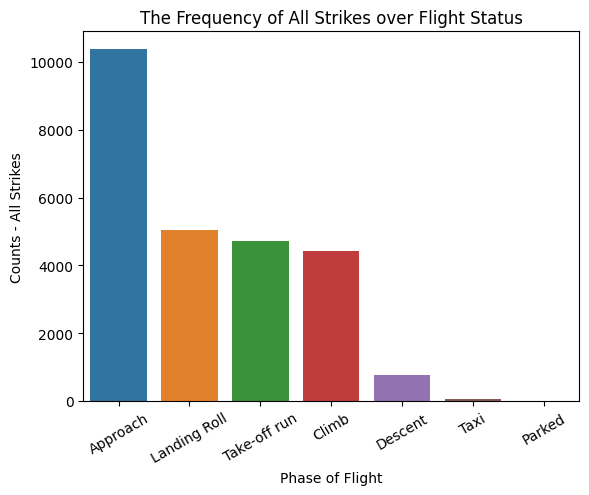

In [ ]:
count_phase = bird['When: Phase of flight'].value_counts()
fig_count = sns.barplot(x=count_phase.index, y=count_phase)
fig_count.set_xticklabels(labels=count_phase.index,rotation=30);
fig_count.set(xlabel='Phase of Flight', ylabel='Counts - All Strikes');
fig_count.set_title('The Frequency of All Strikes over Flight Status');

The above bar plot nicely breaks down the timing of bird strikes. A similar plot is shown for damaging strikes.

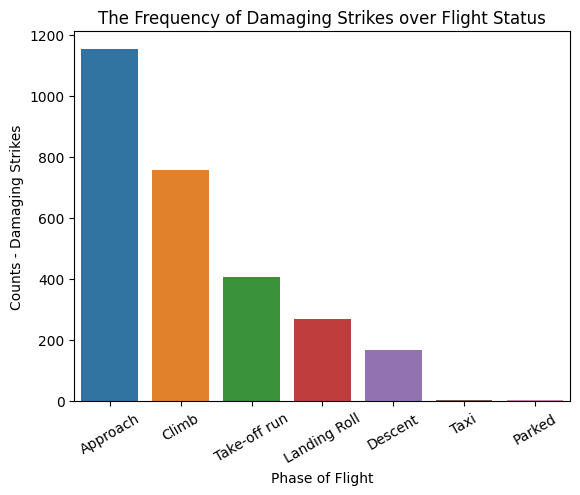

In [ ]:
count_phase0 = bird_dmg['When: Phase of flight'].value_counts()
fig_count0 = sns.barplot(x=count_phase0.index, y=count_phase0)
fig_count0.set_xticklabels(labels=count_phase0.index,rotation=30);
fig_count0.set(xlabel='Phase of Flight', ylabel='Counts - Damaging Strikes');
fig_count0.set_title('The Frequency of Damaging Strikes over Flight Status');

The two bar plots above further show that most of the strikes occur during take-off and landing, especially the Approach phase.

the altitude of the plane and the distance from the airport over the flight phase are shown below.

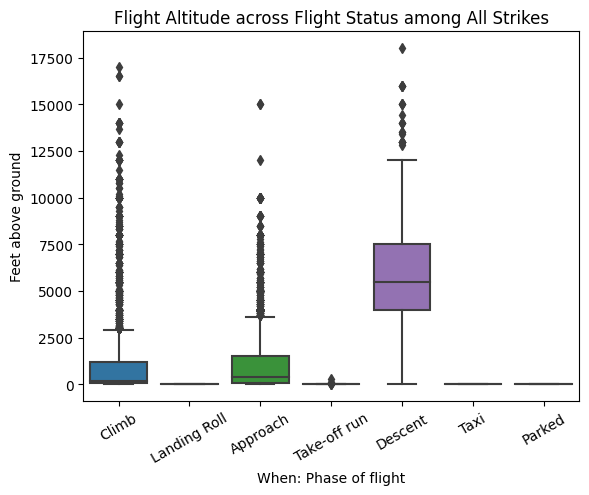

In [ ]:
flight_altitude = sns.boxplot(x="When: Phase of flight", y="Feet above ground", data=bird)
flight_altitude.set_xticklabels(flight_altitude.get_xticklabels(), rotation=30);
flight_altitude.set_title('Flight Altitude across Flight Status among All Strikes');

What are the geological locations of bird strikes? 

In [ ]:
# top 10 airports among all strikes
df_location = pd.DataFrame({'count' : bird.groupby( ['Airport: Name'] ).size()}).reset_index()
df_location.sort_values(['count'], ascending=False).head(10)

,Airport: Name,count
208,DALLAS/FORT WORTH INTL ARPT,803
875,SACRAMENTO INTL,676
882,SALT LAKE CITY INTL,479
232,DENVER INTL AIRPORT,476
497,KANSAS CITY INTL,452
783,PHILADELPHIA INTL,442
749,ORLANDO INTL,408
52,BALTIMORE WASH INTL,401
579,LOUISVILLE INTL ARPT,395
479,JOHN F KENNEDY INTL,390


A similar list of top 10 airports among all damaging strikes is show below:

In [ ]:
# top 10 airports among all damaging strikes
df_airport0 = pd.DataFrame({'count' : bird_dmg.groupby( ['Airport: Name'] ).size()}).reset_index()
df_airport0.sort_values(['count'], ascending=False).head(10)

,Airport: Name,count
538,SACRAMENTO INTL,104
541,SALT LAKE CITY INTL,68
456,ORLANDO INTL,60
280,JOHN F KENNEDY INTL,60
135,DALLAS/FORT WORTH INTL ARPT,56
152,DENVER INTL AIRPORT,36
199,FORT LAUDERDALE/HOLLYWOOD INTL,36
494,PORTLAND INTL (OR),34
311,LAGUARDIA NY,31
291,KANSAS CITY INTL,31


What times do bird strikes occur?

In [ ]:
# month variable
bird['Flight Month'] = pd.DatetimeIndex(bird['FlightDate']).month
# year variable
bird['Flight Year'] = pd.DatetimeIndex(bird['FlightDate']).year

# subset the data with any damage or negative impact to the flight
bird_dmg = bird.loc[(bird['Effect: Indicated Damage'] != 'No damage') | 
                    (bird['Cost: Total $'] > 0) ]

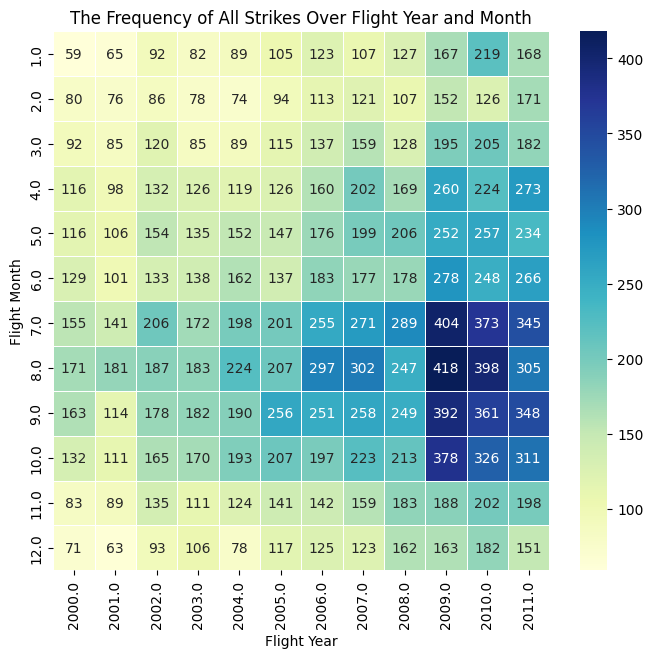

In [ ]:
count_time = pd.DataFrame({'count': bird.groupby(['Flight Month', 'Flight Year']).size()}).reset_index()
count_time_p = count_time.pivot(index="Flight Month", columns="Flight Year", values="count")
plt.figure(figsize=(8, 7))
heat_time = sns.heatmap(count_time_p, cmap="YlGnBu", annot=True, fmt='g', linewidths=.5)
heat_time.set_title('The Frequency of All Strikes Over Flight Year and Month')
plt.show()

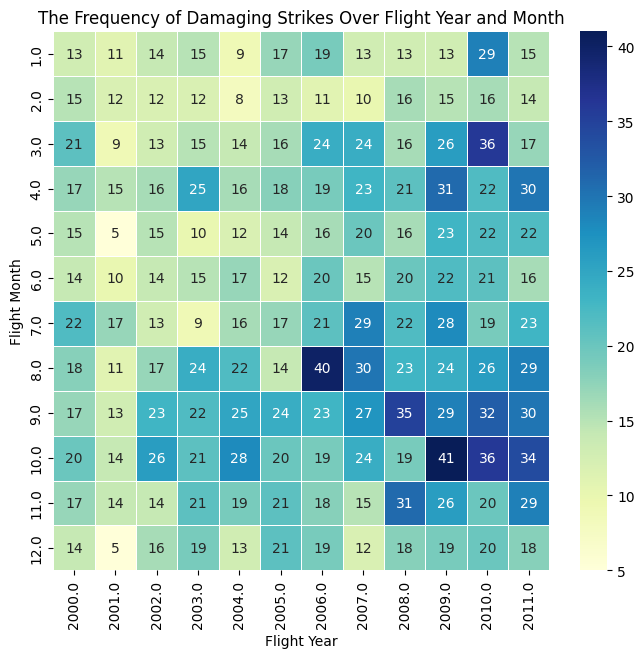

In [ ]:
count_time0 = pd.DataFrame({'count': bird_dmg.groupby(['Flight Month', 'Flight Year']).size()}).reset_index()
count_time_p0 = count_time0.pivot(index="Flight Month", columns="Flight Year", values="count")
plt.figure(figsize=(8, 7))
heat_time0 = sns.heatmap(count_time_p0, cmap="YlGnBu", annot=True, fmt='g', linewidths=.5)
heat_time0.set_title('The Frequency of Damaging Strikes Over Flight Year and Month')
plt.show()

Together, the above analyses show that bird strikes happen mostly between July and October, with an increasing trend from year 2000 to year 2011

C:\Users\Aaminah masarrath\AppData\Local\Temp\ipykernel_27124\2333665132.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  cost = sns.distplot(np.log10(bird.loc[bird['Cost: Total $']>0,'Cost: Total $']),kde=False);


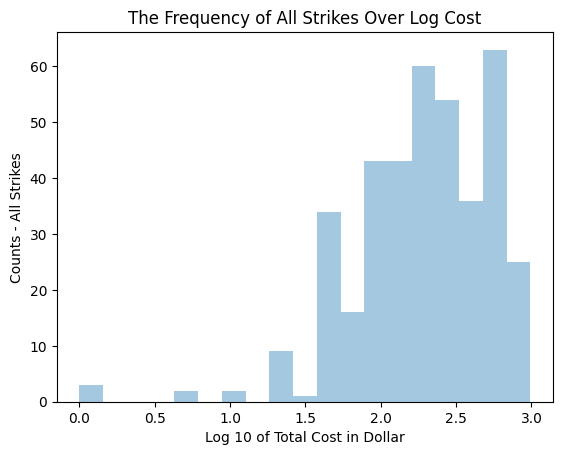

In [ ]:
# cost histogram
cost = sns.distplot(np.log10(bird.loc[bird['Cost: Total $']>0,'Cost: Total $']),kde=False);
cost.set(xlabel='Log 10 of Total Cost in Dollar', ylabel='Counts - All Strikes');
cost.set_title('The Frequency of All Strikes Over Log Cost');

C:\Users\Aaminah masarrath\AppData\Local\Temp\ipykernel_27124\2367819742.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  cost0 = sns.distplot(np.log10(bird_dmg.loc[bird_dmg['Cost: Total $']>0,'Cost: Total $']),kde=False);


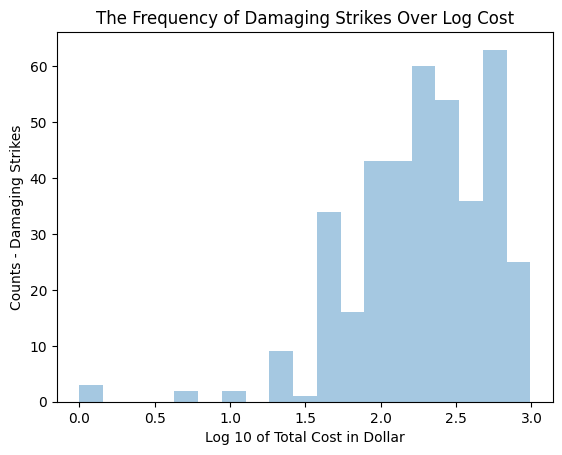

In [ ]:
# cost histogram
cost0 = sns.distplot(np.log10(bird_dmg.loc[bird_dmg['Cost: Total $']>0,'Cost: Total $']),kde=False);
cost0.set(xlabel='Log 10 of Total Cost in Dollar', ylabel='Counts - Damaging Strikes');
cost0.set_title('The Frequency of Damaging Strikes Over Log Cost');

In [ ]:
# damage count table
DataFrame({'count' : bird.groupby( ['Effect: Indicated Damage'] ).size()}).reset_index()

,Effect: Indicated Damage,count
0,Caused damage,2477
1,No damage,23081
